# Synthetic Compact PEST Results Review

Use this notebook after a synthetic compact PEST run finishes. It reopens the run through the built-in `simple_modflow` API, loads the saved targets, and shows the main review surfaces: summary metadata, residual improvement, `K` changes, and example time-series plots.

## Imports And Display Settings

This cell imports the `simple_modflow` review API and a few display helpers. The notebook itself does not rebuild or rerun the model.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import simple_modflow as mf

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


## Choose A Completed Run

By default, this looks for the latest synthetic compact demo run using the `*_latest.txt` pointer written by the workflow. You can also point `run_dir` directly at a specific artifact root, `pest/`, or `pest_master/` folder.

In [2]:
artifact_root = Path(r"C:\Users\lukem\Python\Projects\simple_modflow\examples\mf6\artifacts")
run_family = "synthetic_compact_pest_demo"
latest_pointer = artifact_root / f"{run_family}_latest.txt"

if latest_pointer.exists():
    run_dir = Path(latest_pointer.read_text(encoding="utf-8").strip())
else:
    run_dir = artifact_root / run_family

run_dir

WindowsPath('C:/Users/lukem/Python/Projects/simple_modflow/examples/mf6/artifacts/synthetic_compact_pest_demo_20260521_134004')

## Open The Completed Run

This uses the persisted workspace metadata to reopen the baseline model, calibrated model, and saved head targets. `review()` also assembles the common residual and `K` summaries in one object.

In [3]:
pest_run = mf.open_pest_run(run_dir)
targets = pest_run.load_head_targets()
review = pest_run.review(targets)

baseline_model = review.baseline_model
completed_model = review.calibrated_model

print("Run root:", pest_run.root)
print("Baseline workspace:", pest_run.baseline_workspace)
print("PEST workspace:", pest_run.pest_workspace)
print("Control file:", pest_run.pst_path)
print("Final parameter file:", pest_run.par_path)
print("Saved head-target rows:", len(targets.to_long()))


VoronoiGrid initializing.
Voronoi grid initialized.
VoronoiGrid initializing.
Voronoi grid initialized.
Run root: C:\Users\lukem\Python\Projects\simple_modflow\examples\mf6\artifacts\synthetic_compact_pest_demo_20260521_134004
Baseline workspace: C:\Users\lukem\Python\Projects\simple_modflow\examples\mf6\artifacts\synthetic_compact_pest_demo_20260521_134004\model\syn_demo
PEST workspace: C:\Users\lukem\Python\Projects\simple_modflow\examples\mf6\artifacts\synthetic_compact_pest_demo_20260521_134004\pest_master
Control file: C:\Users\lukem\Python\Projects\simple_modflow\examples\mf6\artifacts\synthetic_compact_pest_demo_20260521_134004\pest_master\synthetic_compact.pst
Final parameter file: C:\Users\lukem\Python\Projects\simple_modflow\examples\mf6\artifacts\synthetic_compact_pest_demo_20260521_134004\pest_master\synthetic_compact.par
Saved head-target rows: 108


## Review Summary

Start here to see whether calibration improved the fit overall. The residual comparison table can also be sorted to find wells or periods that improved the most, or the least.

In [4]:
display(pest_run.summary())
display(review.stats)

residual_view = review.residual_compare.sort_values(
    ["abs_residual_improvement", "time", "name"],
    ascending=[False, True, True],
).reset_index(drop=True)

display(residual_view.head(20))


,root,baseline_workspace,pest_workspace,pst,par,rec,metadata,materialization,n_saved_head_target_sets,has_final_parameters
0,C:\Users\lukem\Python\Projects\simple_modflow\...,C:\Users\lukem\Python\Projects\simple_modflow\...,C:\Users\lukem\Python\Projects\simple_modflow\...,synthetic_compact.pst,synthetic_compact.par,synthetic_compact.rec,simple_modflow_pest_metadata.json,simple_modflow_calibrated_materialization.json,1,True


,n,mean_error_baseline,mae_baseline,rmse_baseline,mean_error_calibrated,mae_calibrated,rmse_calibrated,mae_improvement,rmse_improvement
0,108,0.328319,0.412856,0.508459,-0.001935,0.019372,0.034624,0.393484,0.473835


,time,head_target,name_key,row_label,name,layer,group,weight,x_x,y_x,per,cell,x_y,y_y,sim_head_baseline,residual_baseline,abs_residual_baseline,sim_head_calibrated,residual_calibrated,abs_residual_calibrated,delta_residual,abs_residual_improvement
0,5,91.997040,obs_16,5_16,OBS_16,0,synthetic_heads,1.0,1250.0,1450.0,5,292,1250.0,1450.0,92.933404,0.936364,0.936364,92.015287,0.018247,0.018247,-0.918117,0.918117
1,3,91.953806,obs_16,3_16,OBS_16,0,synthetic_heads,1.0,1250.0,1450.0,3,292,1250.0,1450.0,92.888905,0.935098,0.935098,91.972272,0.018466,0.018466,-0.916633,0.916633
2,4,91.899432,obs_16,4_16,OBS_16,0,synthetic_heads,1.0,1250.0,1450.0,4,292,1250.0,1450.0,92.824387,0.924955,0.924955,91.914055,0.014623,0.014623,-0.910331,0.910331
3,1,91.885421,obs_16,1_16,OBS_16,0,synthetic_heads,1.0,1250.0,1450.0,1,292,1250.0,1450.0,92.809158,0.923737,0.923737,91.9028,0.017379,0.017379,-0.906358,0.906358
4,3,92.275799,obs_05,3_5,OBS_05,0,synthetic_heads,1.0,1350.0,350.0,3,73,1350.0,350.0,93.180791,0.904992,0.904992,92.270929,-0.00487,0.00487,-0.909861,0.900122
5,2,91.830161,obs_16,2_16,OBS_16,0,synthetic_heads,1.0,1250.0,1450.0,2,292,1250.0,1450.0,92.74295,0.912788,0.912788,91.844639,0.014478,0.014478,-0.898311,0.898311
6,0,91.829145,obs_16,0_16,OBS_16,0,synthetic_heads,1.0,1250.0,1450.0,0,292,1250.0,1450.0,92.741995,0.91285,0.91285,91.84529,0.016145,0.016145,-0.896705,0.896705
7,1,92.213904,obs_05,1_5,OBS_05,0,synthetic_heads,1.0,1350.0,350.0,1,73,1350.0,350.0,93.098711,0.884807,0.884807,92.214815,0.000912,0.000912,-0.883895,0.883895
8,5,92.384282,obs_05,5_5,OBS_05,0,synthetic_heads,1.0,1350.0,350.0,5,73,1350.0,350.0,93.270074,0.885792,0.885792,92.387169,0.002888,0.002888,-0.882905,0.882905
9,4,92.280820,obs_05,4_5,OBS_05,0,synthetic_heads,1.0,1350.0,350.0,4,73,1350.0,350.0,93.146662,0.865842,0.865842,92.289071,0.008251,0.008251,-0.857591,0.857591


## K-Field Change

These plots show the calibrated `K` field and the ratio `K_final / K_initial`. The ratio plot is usually the quickest way to see where PEST moved the model.

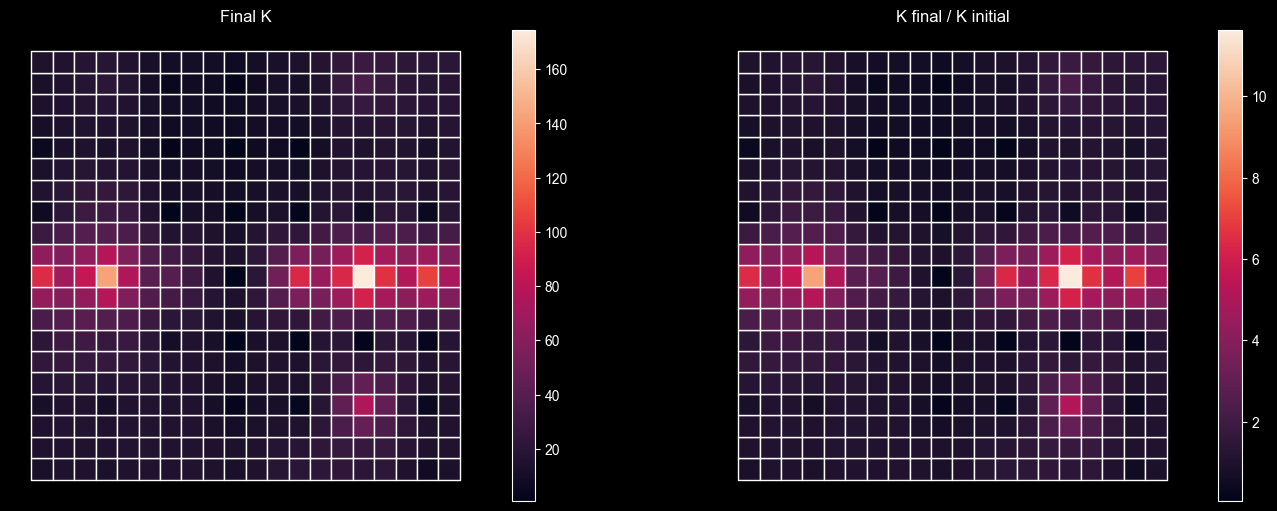

,cell,x,y,k_initial,k_final,k_ratio
count,400.000000,400.000000,400.000000,400.0,400.000000,400.000000
mean,199.500000,1000.000000,1000.000000,15.0,23.864523,1.590968
std,115.614301,577.350269,577.350269,0.0,20.623859,1.374924
min,0.000000,50.000000,50.000000,15.0,0.733491,0.048899
25%,99.750000,525.000000,525.000000,15.0,13.516740,0.901116
50%,199.500000,1000.000000,1000.000000,15.0,17.330409,1.155361
75%,299.250000,1475.000000,1475.000000,15.0,25.157397,1.677160
max,399.000000,1950.000000,1950.000000,15.0,174.556606,11.637107


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
pest_run.plot_k(ax=axes[0])
pest_run.plot_k_ratio(ax=axes[1])
plt.show()

display(review.k_geodata.describe())


## Truth vs Calibrated K

If the workflow wrote the optional review artifacts, this cell compares the calibrated `K` field to the synthetic truth field directly. That makes it easy to see whether calibration only improved fit, or actually recovered the intended structure.

,cell,k_initial,k_final,k_truth,k_ratio,k_final_to_truth
0,0,15.0,12.425082,15.0,0.828339,0.828339
1,1,15.0,14.918693,15.0,0.994580,0.994580
2,2,15.0,15.417019,15.0,1.027801,1.027801
3,3,15.0,13.591975,15.0,0.906132,0.906132
4,4,15.0,15.639207,15.0,1.042614,1.042614
5,5,15.0,16.168499,15.0,1.077900,1.077900
6,6,15.0,15.012436,15.0,1.000829,1.000829
7,7,15.0,15.928728,15.0,1.061915,1.061915
8,8,15.0,14.873787,15.0,0.991586,0.991586
9,9,15.0,12.337957,15.0,0.822530,0.822530


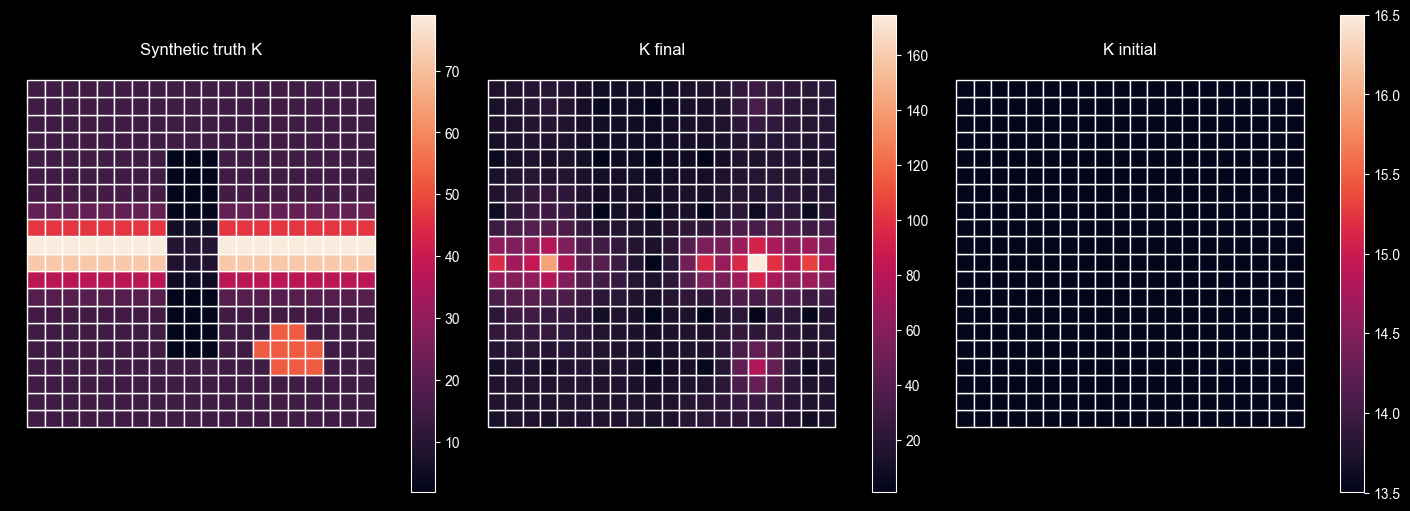

In [13]:
review_dir = pest_run.root / "review"
truth_k_path = review_dir / "truth_k.gpkg"
k_review_path = review_dir / "k_review.gpkg"

if truth_k_path.exists() and k_review_path.exists():
    truth_k = gpd.read_file(truth_k_path)
    k_review = gpd.read_file(k_review_path)
    k_compare = k_review.merge(truth_k[["cell", "k_truth"]], on="cell", how="left")
    k_compare["k_final_to_truth"] = k_compare["k_final"] / k_compare["k_truth"]
    display(k_compare[["cell", "k_initial", "k_final", "k_truth", "k_ratio", "k_final_to_truth"]].head(20))

    fig, axes = plt.subplots(1, 3, figsize=(14, 5), constrained_layout=True)
    k_compare.plot(column="k_truth", ax=axes[0], legend=True)
    axes[0].set_title("Synthetic truth K")
    axes[0].set_axis_off()

    k_compare.plot(column="k_final", ax=axes[1], legend=True)
    axes[1].set_title("K final")
    axes[1].set_axis_off()

    k_compare.plot(column="k_initial", ax=axes[2], legend=True)
    axes[2].set_title("K initial")
    axes[2].set_axis_off()

    plt.show()
else:
    print("Truth-vs-calibrated K artifacts were not found in the review folder.")


## Drain Conductance Review

The synthetic workflow writes a drain summary table so you can see how much each drain feature moved relative to the biased starting conductances.

In [7]:
drain_summary_path = review_dir / "drain_conductance_summary.csv"

if drain_summary_path.exists():
    drain_summary = pd.read_csv(drain_summary_path)
    drain_summary["relative_change"] = (
        (drain_summary["final_cond"] - drain_summary["start_cond"]).abs()
        / drain_summary["start_cond"]
    )
    display(drain_summary)
else:
    print("Drain conductance summary was not found in the review folder.")


,name,start_cond,truth_cond,final_multiplier,final_cond,relative_change
0,north_relief,220.0,80.0,1.0,220.0,0.0
1,central_valley,140.0,360.0,1.0,140.0,0.0
2,south_capture,180.0,950.0,1.0,180.0,0.0


## Period And Well Diagnostics

These plots help answer the usual calibration questions: which periods improved, and what happened at a specific observation point through time.

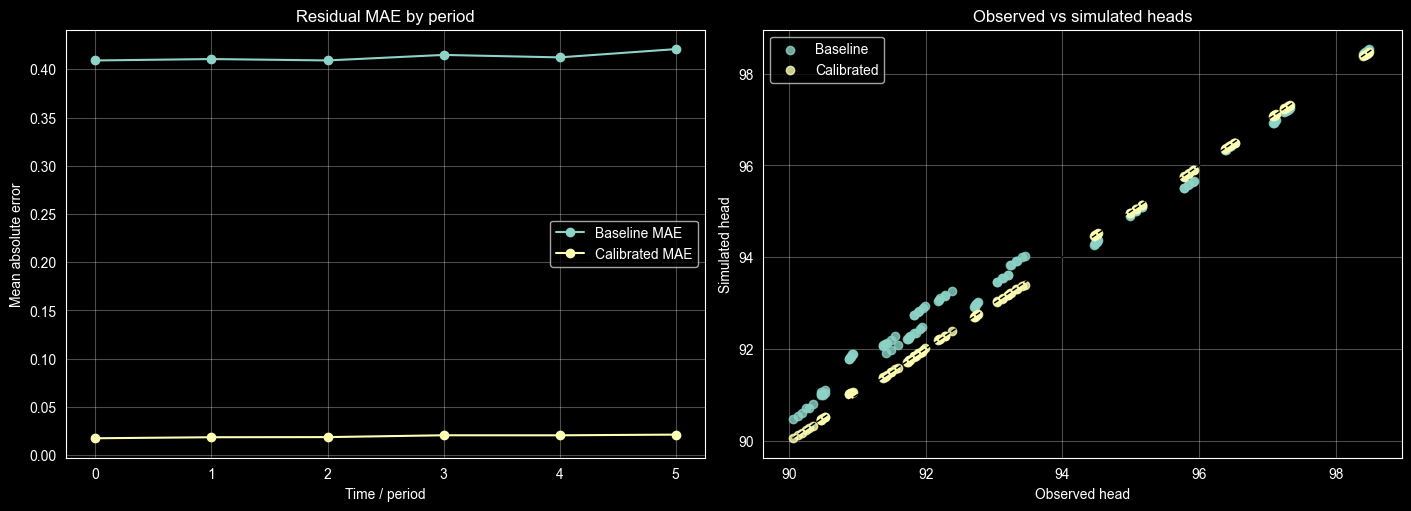

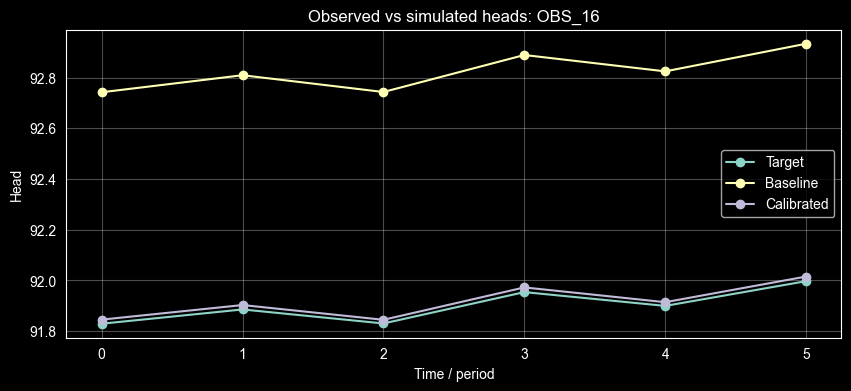

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
pest_run.plot_residuals_by_period(targets=targets, ax=axes[0])
pest_run.plot_obs_vs_sim(targets=targets, ax=axes[1])
plt.show()

well_name = residual_view.loc[0, "name"] if not residual_view.empty else targets.to_long()["name"].iloc[0]
fig, ax = plt.subplots(figsize=(10, 4))
pest_run.plot_well_timeseries(well_name, targets=targets, ax=ax)
ax.set_title(f"Observed vs simulated heads: {well_name}")
plt.show()
